In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN


In [4]:
df = pd.read_csv('../Data/CC GENERAL.csv')
df.drop('CUST_ID', axis=1, inplace=True)

filtro_cero_pagos = (df['MINIMUM_PAYMENTS'].isnull()) & (df['PAYMENTS'] == 0.0)
df.loc[filtro_cero_pagos, 'MINIMUM_PAYMENTS'] = 0.0
df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median(), inplace=True)

df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median(), inplace=True)

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

pca = PCA(n_components=10, random_state=42)
df_pca = pca.fit_transform(df_scaled)



C:\Users\USER\AppData\Local\Temp\ipykernel_17780\521742752.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median(), inplace=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_17780\521742752.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

In [5]:
dbscan = DBSCAN(eps=0.5, min_samples=10)
df['Cluster_DBSCAN'] = dbscan.fit_predict(df_pca)

print("--- POBLACIÓN DE LOS CLUSTERS (DBSCAN) ---")
print(df['Cluster_DBSCAN'].value_counts())

--- POBLACIÓN DE LOS CLUSTERS (DBSCAN) ---
Cluster_DBSCAN
-1     6346
 0     2099
 1      285
 9       43
 3       40
 4       32
 5       32
 2       20
 8       16
 6       12
 10      10
 11       9
 7        6
Name: count, dtype: int64


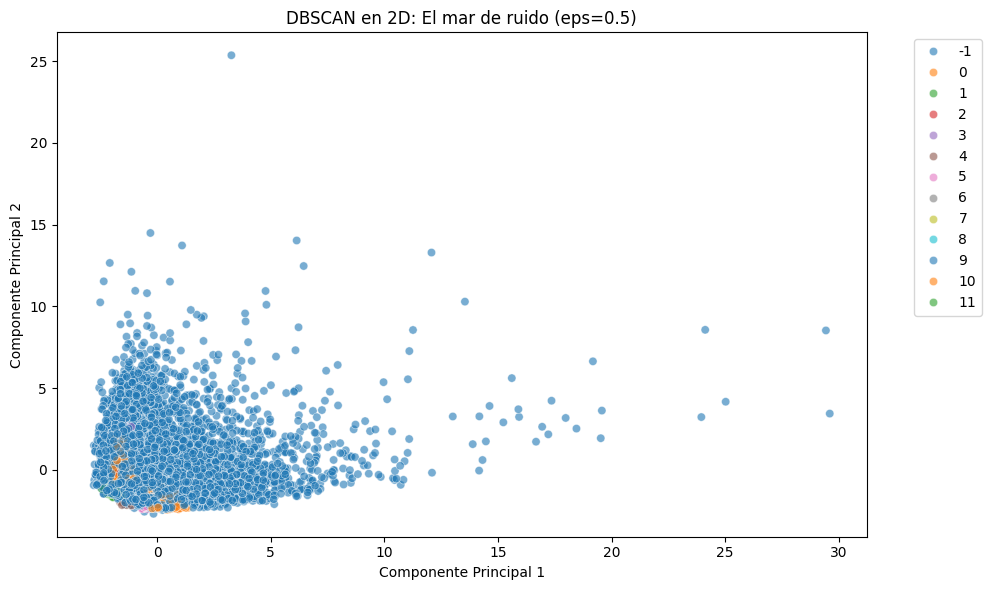

In [12]:

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df_pca[:, 0], # Extracción directa de la primera columna del array NumPy
    y=df_pca[:, 1], # Extracción directa de la segunda columna
    hue=df['Cluster_DBSCAN'], 
    palette='tab10', 
    alpha=0.6
)
plt.title('DBSCAN en 2D: El mar de ruido (eps=0.5)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



In [11]:
from sklearn.neighbors import NearestNeighbors

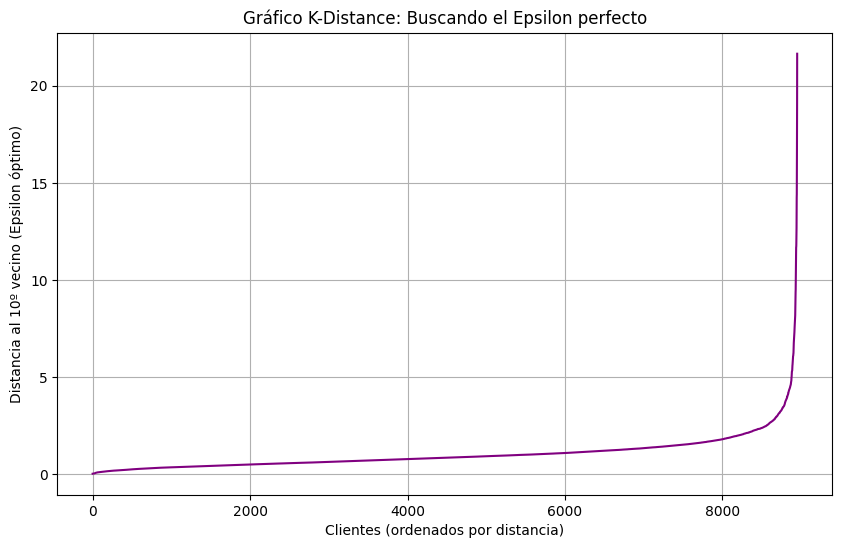

In [13]:
vecinos = NearestNeighbors(n_neighbors=10)
vecinos_fit = vecinos.fit(df_pca)
distancias, indices = vecinos_fit.kneighbors(df_pca)
distancias_ordenadas = np.sort(distancias[:, 9], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distancias_ordenadas, color='purple')
plt.title('Gráfico K-Distance: Buscando el Epsilon perfecto')
plt.xlabel('Clientes (ordenados por distancia)')
plt.ylabel('Distancia al 10º vecino (Epsilon óptimo)')
plt.grid(True)
plt.show()

--- CENSO DEFINITIVO: DBSCAN (eps=2.5) ---
Cluster_DBSCAN
 0    8720
-1     230
Name: count, dtype: int64


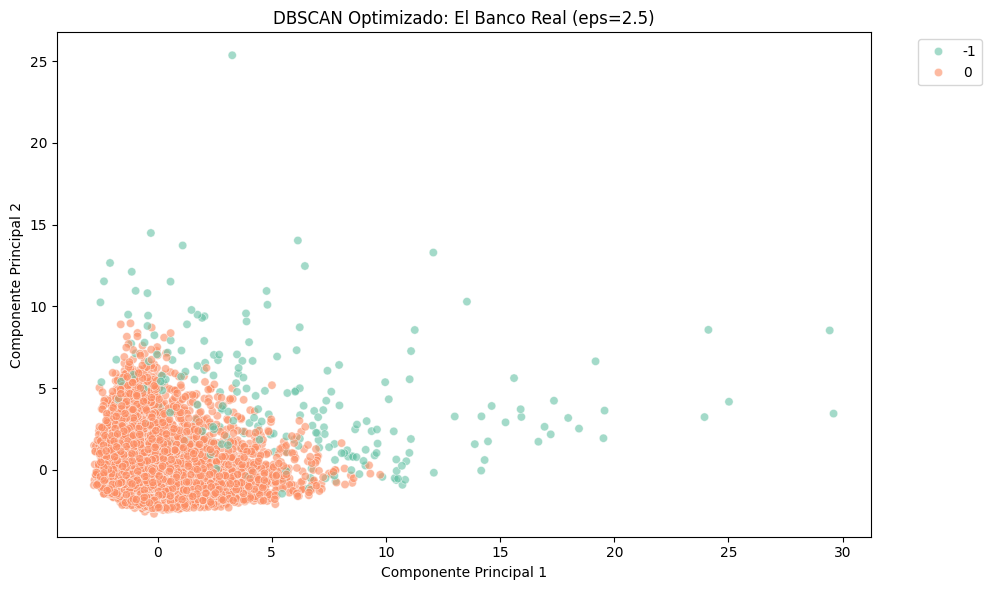

In [25]:
dbscan_final = DBSCAN(eps=2.5, min_samples=10)
df['Cluster_DBSCAN'] = dbscan_final.fit_predict(df_pca)

print("--- CENSO DEFINITIVO: DBSCAN (eps=2.5) ---")
print(df['Cluster_DBSCAN'].value_counts())

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df_pca[:, 0], 
    y=df_pca[:, 1], 
    hue=df['Cluster_DBSCAN'], 
    palette='Set2', 
    alpha=0.6
)
plt.title('DBSCAN Optimizado: El Banco Real (eps=2.5)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [26]:

from sklearn.metrics import silhouette_score


epsilons = np.arange(2.0, 3.1, 0.1)
resultados_dbscan = []

for e in epsilons:
    dbscan_prueba = DBSCAN(eps=e, min_samples=10)
    etiquetas = dbscan_prueba.fit_predict(df_pca)
    
    clusters_reales = len(set(etiquetas)) - (1 if -1 in etiquetas else 0)
    ruido_total = list(etiquetas).count(-1)
    
    if clusters_reales > 1:
        mascara_sin_ruido = etiquetas != -1
        score = silhouette_score(df_pca[mascara_sin_ruido], etiquetas[mascara_sin_ruido])
    else:
        score = -1.0 
        
    resultados_dbscan.append({
        'Epsilon': round(e, 2), 
        'Clusters_Utiles': clusters_reales, 
        'Total_Ruido': ruido_total, 
        'Silhouette_Score': score
    })

df_resultados = pd.DataFrame(resultados_dbscan)
print("--- AUDITORÍA MATEMÁTICA DE DBSCAN ---")
print(df_resultados.sort_values(by='Silhouette_Score', ascending=False).to_string(index=False))

--- AUDITORÍA MATEMÁTICA DE DBSCAN ---
 Epsilon  Clusters_Utiles  Total_Ruido  Silhouette_Score
     2.0                1          413              -1.0
     2.1                1          363              -1.0
     2.2                1          319              -1.0
     2.3                1          293              -1.0
     2.4                1          262              -1.0
     2.5                1          230              -1.0
     2.6                1          206              -1.0
     2.7                1          190              -1.0
     2.8                1          170              -1.0
     2.9                1          160              -1.0
     3.0                1          145              -1.0
